# KNeighborsClassifier

Dataset - load_iris

# 🤖 KNN (K-Nearest Neighbors) — Шпаргалка

## 1. Негізгі анықтама
**KNN** — классификация және регрессия есептерін шешуге арналған метрикалық алгоритм. Ол жаңа нысанды оған ең жақын орналасқан $k$ дана көршісінің класына жатқызады.

* **Типі:** Lazy Learner (Жалқау оқытушы). Модель алдын ала ештеңе үйренбейді, барлық есептеуді болжам жасау кезінде орындайды.
* **Гиперпараметр:** $k$ (көршілер саны).

---

## 2. Жұмыс істеу алгоритмі
1.  **k** санын таңдау (мысалы, $k=3$ немесе $k=5$).
2.  Жаңа дерек пен жаттықтыру жиынтығындағы әрбір нүкте арасындағы **қашықтықты** есептеу.
3.  Ең жақын **k** көршіні таңдау.
4.  **Дауыс беру:** Жаңа нысанды көпшілік көршілер жататын класқа беру.

---

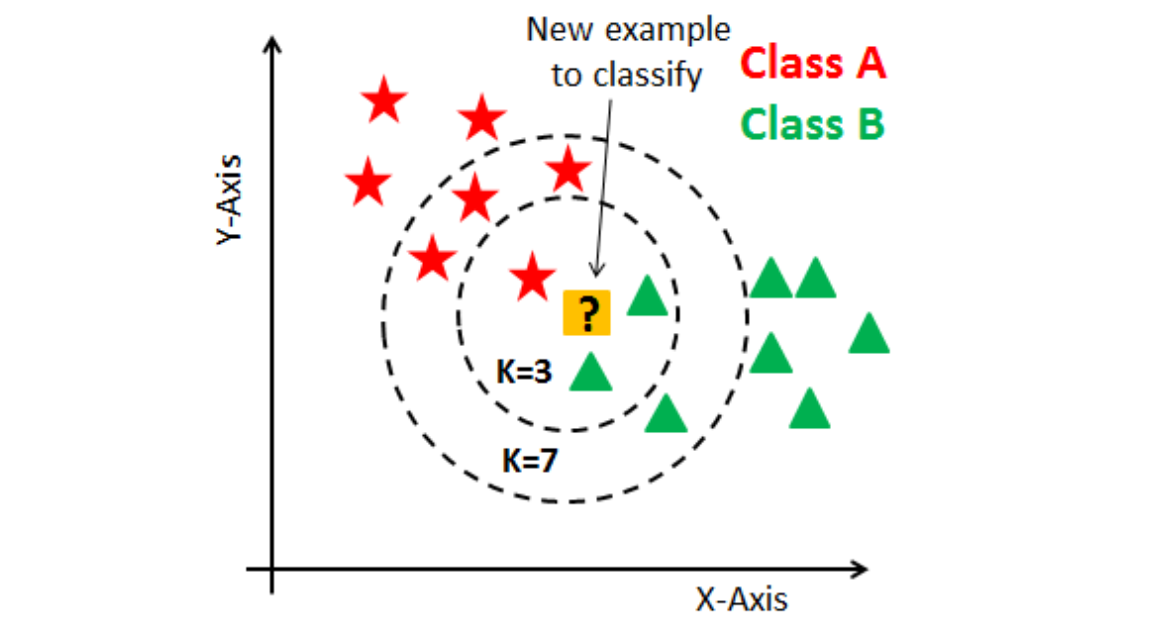

## 3. Математикалық негізі (Қашықтық түрлері)
KNN үшін ең маңыздысы — нүктелер арасындағы қашықтық.

* **Евклид қашықтығы** (Ең көп қолданылатыны):
    $$d(p,q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$
* **Манхэттен қашықтығы**:
    $$d(p,q) = \sum_{i=1}^{n} |p_i - q_i|$$

---

## 4. Маңызды ережелер (Cheat Sheet Tips) 💡
* **Scaling (Масштабтау):** МІНДЕТТІ түрде қажет. Егер бір баған 0-1 арасында, ал екіншісі 0-1000 арасында болса, үлкен сандар қашықтықты есептегенде басымдыққа ие болып, нәтижені бұзады. (`StandardScaler` қолданыңыз).
* **k таңдау:**
    * $k$ тым кішкентай болса = **Overfitting** (шуға сезімтал).
    * $k$ тым үлкен болса = **Underfitting** (шекаралар жойылып кетеді).
    * Әдетте $k = \sqrt{n}$ (мұндағы $n$ - деректер саны) немесе тақ сан таңдалады.
* **Деректердің тазалығы:** KNN "шулы" деректерге және ауытқуларға (outliers) өте сезімтал.

---

## 5. Scikit-learn коды (Шаблон)
```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Масштабтау
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Модельді құру (k=5)
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

# 3. Оқыту және Болжам
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# 🛠 KNN: Параметрлер, Функциялар және Метрикалар

Scikit-learn кітапханасындағы KNN-нің ең маңызды құрамдас бөліктері:

---

## 1. Негізгі Гиперпараметрлер (Параметрлер)
Модельді құрғанда келесі аргументтерді теңшей аламыз:
`knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', p=2)`

* **n_neighbors ($k$):** Көршілер саны. Әдетте 3, 5 немесе 7 таңдалады.
* **weights:** Көршілердің "салмағы".
    * `'uniform'`: Барлық көршілердің дауысы тең.
    * `'distance'`: Жақын тұрған көршілердің дауысы алыстағыларға қарағанда маңыздырақ болады.
* **metric:** Қашықтықты өлшеу әдісі.
    * `'euclidean'`: Тікелей қашықтық.
    * `'manhattan'`: Көшелермен жүргендей қашықтық.
    * `'minkowski'`: Жалпыланған формула (әдепкі бойынша осы тұрады).
* **p:** Минковский метрикасының дәрежесі.
    * `p=1`: Манхэттен қашықтығы.
    * `p=2`: Евклид қашықтығы.

---

## 2. Негізгі Функциялар (Әдістер)
Модельмен жұмыс істеудің стандартты қадамдары:

1.  **fit(X, y):** Модельді жаттықтыру. KNN жағдайында ол жай ғана деректерді жадына сақтап алады.
2.  **predict(X):** Жаңа деректердің қай класқа жататынын болжайды.
3.  **predict_proba(X):** Класқа жату ықтималдығын көрсетеді (мысалы, "қызыл" болуы 80%, "көк" болуы 20%).
4.  **kneighbors(X):** Берілген нүктеге ең жақын $k$ көршінің индекстері мен оларға дейінгі қашықтықты қайтарады (талдау үшін өте пайдалы).

---

## 3. Бағалау Метрикалары (Metrics)
Модельдің қаншалықты жақсы жұмыс істеп тұрғанын қалай білеміз?

* **Accuracy (Дәлдік):** Жалпы дұрыс болжамдардың үлесі.
* **Confusion Matrix:** Қай кластар бір-бірімен жиі ауысып кеткенін көрсететін кесте.
* **F1-Score:** Егер деректер теңгерімсіз болса (мысалы, бір класс өте көп, екіншісі аз), тек қана Accuracy-ге сенуге болмайды, осы метриканы қолдану керек.

---

## 4. Практикалық Код Мысалы
```python
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Модельді баптау
model = KNeighborsClassifier(n_neighbors=3, weights='distance')

# Оқыту
model.fit(X_train_scaled, y_train)

# Болжам жасау
y_pred = model.predict(X_test_scaled)

# Нәтижені тексеру (Метрикалар)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [11]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
# Деректер өлшемі
df.shape

(150, 5)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [14]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [24]:
# Деректерді масштабтау және бөлу
X, y = df.drop('target', axis=1), df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [25]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [26]:
y_pred = knn3.predict(X_test)

In [28]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted')}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")

Accuracy: 1.0
F1 Score: 1.0
Confusion Matrix: 
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


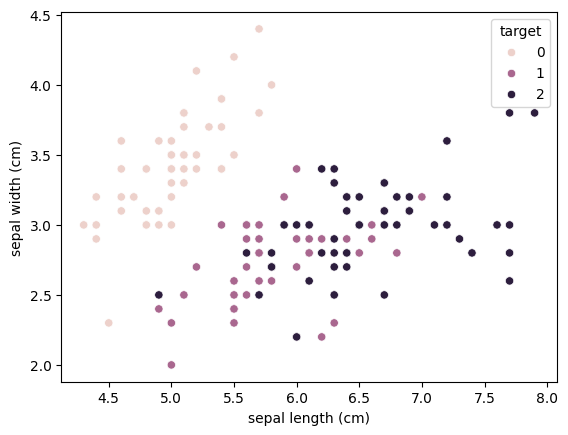

In [29]:
sns.scatterplot(x=df['sepal length (cm)'], y=df['sepal width (cm)'], hue=df['target'])
plt.show()

### KNN Моделінің Қорытындысы (Iris Dataset)

**Модель сипаттамасы:**
- Алгоритм: K-Nearest Neighbors (KNN)
- Көршілер саны ($k$): 5 (немесе сіз таңдаған сан)
- Деректер: StandardScaler арқылы масштабталған

**Нәтижелер:**
- **Accuracy:** 1.0 — Тест деректерін толық қатесіз таныды.
- **F1-Score:** 1.0 — Кластарды ажырату қабілеті максималды деңгейде.
- **Confusion Matrix:** Барлық 30 тест нысаны (10 Setosa, 9 Versicolor, 11 Virginica) өз топтарына дұрыс бөлінді.

**Қорытынды:**
Модель Iris деректеріндегі заңдылықтарды өте жақсы меңгерген. Сабақ немесе жоба үшін бұл — ең жоғарғы көрсеткіш.

In [31]:
import joblib

# Модельді сақтау (мысалы, 'knn_model.pkl' деген атпен)
joblib.dump(knn3, 'iris_knn_model.pkl')

# Сондай-ақ, StandardScaler-ді де сақтауды ұмытпаңыз!
# Себебі жаңа деректерді де дәл осы шкаламен масштабтау керек.
joblib.dump(scaler, 'iris_scaler.pkl')

print("Модель мен Scaler сәтті сақталды!")

Модель мен Scaler сәтті сақталды!


# Heart Dataset + KNN
Dataset - [heart.csv](https://github.com/sharmaroshan/Heart-UCI-Dataset/blob/master/heart.csv)

In [33]:
data = pd.read_csv("/content/heart.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [39]:
# Деректерді features, target бөлу
X, y = data.drop('target', axis=1), data['target']

# Деректерді масштабтау
scaler_heart = StandardScaler()
X_scaled_h = scaler_heart.fit_transform(X)

# Деректерді оқыту & тестілеуге бөлу
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [40]:
# Модельді құрамыз және оқытамыз
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)

KNeighborsClassifier()

In [41]:
# Тестілеу өткіземіз
y_pred = knn5.predict(X_test)

In [42]:
# Метрикалар
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted')}")
print(f"Confusion Matrix: \n{confusion_matrix(y_test, y_pred)}")

Accuracy: 0.6885245901639344
F1 Score: 0.6870031363302711
Confusion Matrix: 
[[18 11]
 [ 8 24]]


Әзірге модель орташа деңгейде 68% көрсетіп тұр енді кішкене анализ үшін бірнеше модель құрастырамыз, әртүрлі гиперпараметрлермен

In [53]:
accuracy = []
f1 = []
neighbors = [3, 4, 5, 6, 7]
for n in neighbors:
  model = KNeighborsClassifier(n_neighbors=n)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred, average='weighted'))

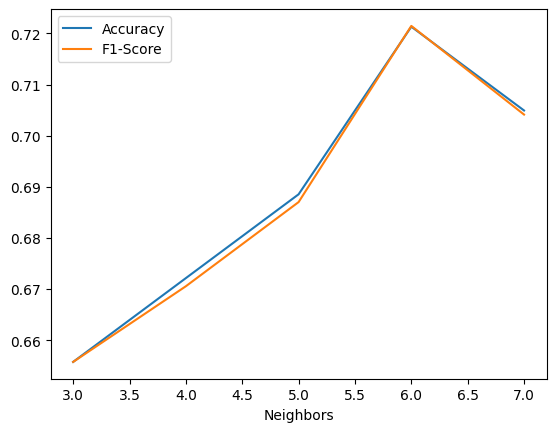

In [58]:
plt.plot(neighbors, accuracy, label='Accuracy')
plt.xlabel("Neighbors")
plt.legend()
plt.plot(neighbors, f1, label="F1-Score")
plt.legend()
plt.show()